In questo esercizio si costruisce un modello approssimato per l’orizzonte sonoro rs in funzione dei parametri cosmologici, a partire da simulazioni numeriche (CAMB) e usando un fit logaritmico per interpolare in modo efficiente lo spazio dei parametri.

In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm 

In [8]:
!pip install camb
!pip install iminuit

In [ ]:
import camb, iminuit # iminuit per ottimizzazione numerica

In [ ]:
def model_rs(ombh2,ombch2,nnu, z_star):
  # simile a quello in file 4_cmb_likelihoood.ipynb
  camb_params = camb.CAMBparams()  
  camb_params.set_cosmology(ombh2=ombh2,omch2=ombch2-ombh2,nnu=nnu,num_massive_neutrinos=0,mnu=0,H0=70)  #**params ="usa ogni chiave-valore come argomento della funzione"
  camb_result = camb.get_background(camb_params)  
  rs_star = camb_result.sound_horizon(z_star)
  return rs_star

# dove: ombch2 = ombh2 + omch2,  nnu= numero di specie di neutrini, mnu = massa dei neutrini, num_massive_neutrinos = numero di neutrini massivi

In [ ]:
model_rs(0.022,0.14,3,1089) 

np.float64(145.57805909819115)

In [ ]:
wb_limits=[0.02,0.024] 
wbc_limits=[0.1,0.18]
Neff_limits=[3,3.1]  # limiti per il numero efficace di neutrini
# dove Neff=parametro fisico che rappresenta la densità di radiazione relativistica oltre ai fotoni, espressa come "equivalente in neutrini"

n_samples=15
grid=np.linspace(0,1,n_samples)

# Creazione di griglie per i parametri cosmologici
wb_grid=grid*(wb_limits[1]-wb_limits[0])+wb_limits[0] # 
wbc_grid=grid*(wbc_limits[1]-wbc_limits[0])+wbc_limits[0]
Neff_grid=grid*(Neff_limits[1]-Neff_limits[0])+Neff_limits[0]


CPU times: user 6min 33s, sys: 4.76 s, total: 6min 38s
Wall time: 50.6 s


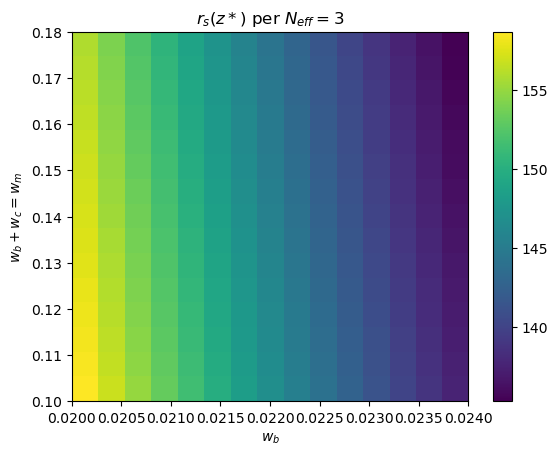

In [30]:
%%time   
# Misura quanto tempo impiega questo blocco a essere eseguito

n=0

rs=np.zeros(shape=(n_samples,n_samples,n_samples)) # Inizializza array 3D per valori del sound horizon
for i in range(n_samples):      # Cicla sui valori di w_b
  for j in range(n_samples):    # Cicla sui valori di w_b + w_c
    for k in range(n_samples):  # Cicla sui valori di Neff
      rs[i,j,k]=model_rs(wb_grid[i],wbc_grid[j],Neff_grid[k],1089)  # Calcola rs per ciascuna combinazione

# Visualizza una sezione della griglia (per un Neff fissato, il primo valore della griglia)
plt.imshow(rs[:,:,0],origin='lower',aspect='auto',extent=[wb_limits[0],wb_limits[1],wbc_limits[0],wbc_limits[1]] )  
plt.xlabel(r"$w_b$")
plt.ylabel(r"$w_b+w_c=w_m$")
plt.title(r"$r_s(z*)$ per $N_{eff}=3$")  
plt.colorbar()

In [ ]:
# Definisco i valori "di riferimento" per wb, wbc, Neff — quelli centrali nel range esplorato
wb_ref=0.02236
wbc_ref=0.1432
Neff_ref=3.04

# Calcolo rs teorico associato a questi parametri centrali (per modello analitico)
rs_ref=model_rs(wb_ref,wbc_ref,Neff_ref,1089)

In [ ]:
from scipy.optimize import minimize

# Definisce un modello analitico per log10(rs), in funzione di tre parametri da stimare (theta)
def model_log_rs_analytical(theta, ombh2,ombch2,Neff):
  return np.log10(rs_ref)+theta[0]*np.log10(ombh2/wb_ref)+theta[1]*np.log10(ombch2/wbc_ref)+theta[2]*np.log10(Neff/Neff_ref)

In [ ]:
# Definisce una funzione da minimizzare: lo scarto quadratico tra il log10(rs) teorico e il modello analitico
def func(p1,p2,p3): 
  log_rs_analytical=np.zeros(shape=(n_samples,n_samples,n_samples))
  for i in range(n_samples):
    for j in range(n_samples):
      for k in range(n_samples):
        # Calcola il valore previsto dal modello analitico per ogni punto della griglia
        log_rs_analytical[i,j,k]=model_log_rs_analytical([p1,p2,p3],wb_grid[i],wbc_grid[j],Neff_grid[k])
  
  return np.sum((log_rs_analytical-np.log10(rs))**2) # Ritorna la somma degli scarti quadrati (errore totale)

In [ ]:
# Calcola l’errore iniziale del modello con dei valori iniziali per i parametri (p1, p2, p3)
func(-0.13, -0.23, -0.1)

np.float64(0.008253712720433962)

In [ ]:
from iminuit import Minuit as mm # Importa Minuit

# Istanzia l'oggetto Minuit con la funzione da minimizzare e i valori iniziali dei parametri
mm=mm(func,p1=-0.13,p2=-0.23,p3=-0.1)

# Esegue la procedura di minimizzazione per trovare i migliori coefficienti
mm.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.0023                     │              Nfcn = 38               │
│ EDM = 3.13e-05 (Goal: 0.0002)    │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p1   │   -0.1    │    0.7    │            │            │         │         │       │
│ 1 │ p2   │   -0.24   │   0.22    │            │            │         │         │       │
│ 2 │ p3   │    -0     │     4     │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬──────────────────────┐
│    │     p1     p2     p3 │
├────┼──────────────────────┤
│ p1 │  0.457  -0.01    0.2 │
│ p2 │  -0.01 0.0465   0.05 │
│ p3 │    0.2   0.05   14.1 │
└────┴──────────────────────┘

In [ ]:
# Mostra i valori ottimali trovati per i tre parametri del modello analitico
mm.values

<ValueView p1=-0.08995932377618496 p2=-0.239498934407149 p3=-0.15143606909002322>

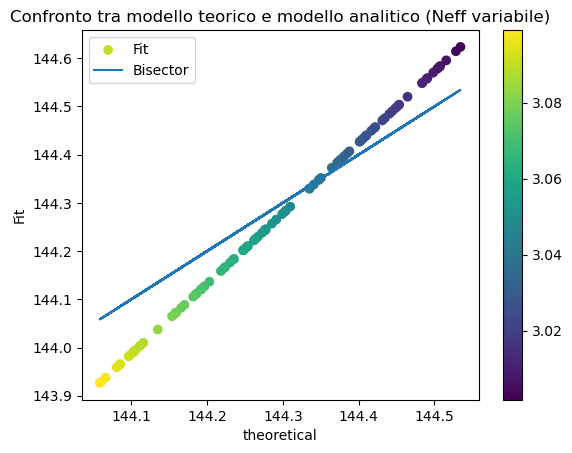

In [38]:
Neff_random=np.random.uniform(Neff_limits[0],Neff_limits[1],100)

# Calcola rs teorico usando model_rs per ogni valore di Neff (tenendo wb e wbc fissi)
rs_random=np.array([model_rs(wb_ref,wbc_ref,Neff_random[i],1089) for i in range(100)])

# Calcola rs dal modello analitico (fit), usando gli stessi valori di Neff
rs_analytical=10**np.array([model_log_rs_analytical(mm.values,wb_ref,wbc_ref,Neff_random[i]) for i in range(100)])

cb=plt.scatter(rs_random,rs_analytical,label="Fit",c=Neff_random) # Colore in base a Neff
plt.colorbar(cb)
plt.plot(rs_random,rs_random,label="Bisector") # Aggiunge la bisettrice (dove teoria e fit coincidono)
plt.xlabel("theoretical")
plt.ylabel("Fit")
plt.title("Confronto tra modello teorico e modello analitico (Neff variabile)")
plt.legend()

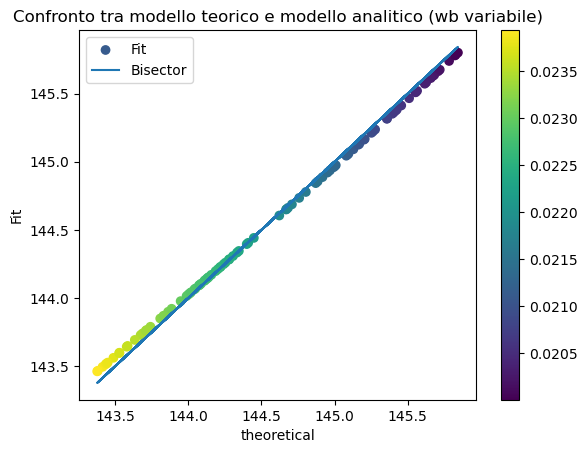

In [39]:
wb_random=np.random.uniform(wb_limits[0],wb_limits[1],100)

# Calcola rs teorico con wb variabile, Neff e wbc fissati
rs2_random=np.array([model_rs(wb_random[i],wbc_ref,Neff_ref,1089) for i in range(100)])

rs2_analytical=10**np.array([model_log_rs_analytical(mm.values,wb_random[i],wbc_ref,Neff_ref) for i in range(100)])

cb=plt.scatter(rs2_random,rs2_analytical,label="Fit",c=wb_random)
plt.colorbar(cb)
plt.plot(rs2_random,rs2_random,label="Bisector")
plt.xlabel("theoretical")
plt.ylabel("Fit")
plt.title("Confronto tra modello teorico e modello analitico (wb variabile)")
plt.legend()

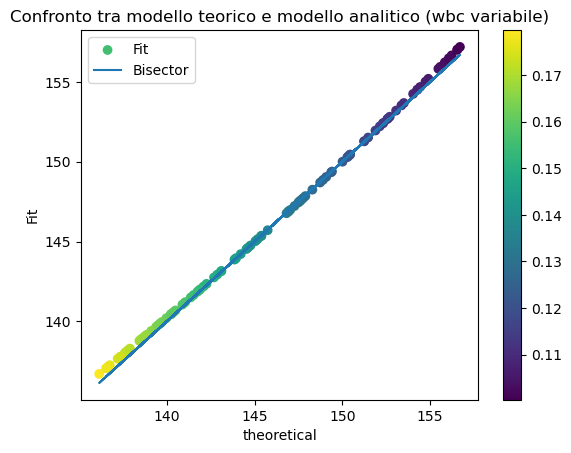

In [40]:
wbc_random=np.random.uniform(wbc_limits[0],wbc_limits[1],100)

# Calcola rs teorico con wbc variabile, wb e Neff fissi
rs3_random=np.array([model_rs(wb_ref,wbc_random[i],Neff_ref,1089) for i in range(100)])

rs3_analytical=10**np.array([model_log_rs_analytical(mm.values,wb_ref,wbc_random[i],Neff_ref) for i in range(100)])

cb=plt.scatter(rs3_random,rs3_analytical,label="Fit",c=wbc_random)
plt.colorbar(cb)
plt.plot(rs3_random,rs3_random,label="Bisector")
plt.xlabel("theoretical")
plt.ylabel("Fit")
plt.title("Confronto tra modello teorico e modello analitico (wbc variabile)")
plt.legend()

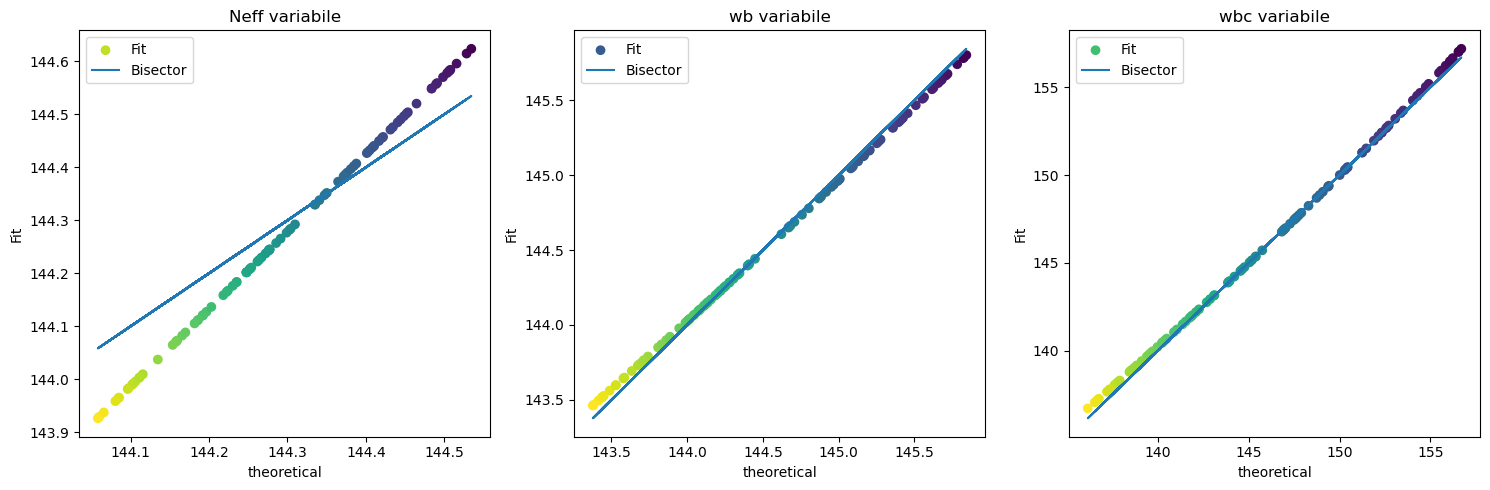

In [44]:
# Metto i tre grafici in un'unica figura
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].scatter(rs_random,rs_analytical,label="Fit",c=Neff_random)
axs[0].plot(rs_random,rs_random,label="Bisector")
axs[0].set_xlabel("theoretical")
axs[0].set_ylabel("Fit")
axs[0].set_title("Neff variabile")
axs[0].legend()

axs[1].scatter(rs2_random,rs2_analytical,label="Fit",c=wb_random)
axs[1].plot(rs2_random,rs2_random,label="Bisector")
axs[1].set_xlabel("theoretical")
axs[1].set_ylabel("Fit")
axs[1].set_title("wb variabile")
axs[1].legend()

axs[2].scatter(rs3_random,rs3_analytical,label="Fit",c=wbc_random)       
axs[2].plot(rs3_random,rs3_random,label="Bisector")
axs[2].set_xlabel("theoretical")
axs[2].set_ylabel("Fit")
axs[2].set_title("wbc variabile")
axs[2].legend() 

plt.tight_layout()  
plt.show()  

NB: Il modello analitico approssimato log10(rs)=log10(wb),log10(wbc),log10(Neff) funziona molto bene per wb e wc, ma non per Neff.